# Information and identifiability: the un-inverted view

Some vocabulary up front. An NLP is a nonlinear program: an
optimization problem whose equations are nonlinear, and fitting a
model to data by least squares is one. After a fit,
`covariance(model)` reports how UNCERTAIN each fitted parameter is,
its variance given the noise in the data, and `information(model)`
reports the opposite object: how strongly the data pins each parameter
down. The two matrices are inverses of each other (up to the noise
scale), which is why we call information the un-inverted view; POUNCE
computes it directly from the solver's own second-derivative
information rather than by inverting the covariance.

Two situations where information says more than covariance:

1. A POORLY IDENTIFIED fit. When the data barely distinguishes two
   parameters, the covariance shows every parameter correlated with
   every other; the information matrix's `eigen()` finds the near-zero
   eigenvalue and its eigenvector NAMES the combination the data
   cannot pin down (here: trade `a` for `b`, compensated by moving
   `k2`).
2. A parameter at a bound, a simple limit like $b \ge 2$ that the
   solution presses against. The covariance reports zero variance
   (the uncertainty IF the bound is taken as given), which hides how
   much the data actually says; the information matrix returns S, the
   information about that parameter on its own, because zero variance
   is NOT zero information.

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo

import pyomo_pounce  # registers 'pounce' with SolverFactory
from pyomo_pounce import (
    covariance, declare_fitted, declare_residual, information)

rng = np.random.default_rng(11)
A_TRUE, B_TRUE, K1_TRUE, K2_TRUE = 2.0, 1.0, 0.8, 1.6
t_data = np.linspace(0.0, 5.0, 40)
y_data = (A_TRUE * np.exp(-K1_TRUE * t_data)
          + B_TRUE * np.exp(-K2_TRUE * t_data)
          + 0.02 * rng.standard_normal(len(t_data)))

## 1. A poorly identified two-exponential fit

One model, fit once. Its prediction is a sum of two exponential terms,

$$\hat y(t) = a\; e^{-k_1 t} + b\; e^{-k_2 t},$$

with all four parameters $(a, b, k_1, k_2)$ fitted together in one
least-squares solve. The residual variables carry the misfit, one per
data point: a residual is the gap between a measurement and the
model's prediction for it, and least squares minimizes the sum of
their squares,

$$r_i = y_i - \hat y(t_i),\qquad \min \sum_i r_i^2.$$

"Poorly identified" means different parameter values produce almost
the same predictions, so the data cannot tell them apart. That happens
here because the two rates sit within a factor of two of each other,
making the two terms similar in shape. After the solve, the standard
errors (the +/- numbers) look alarming, and the correlation matrix,
which measures how strongly each pair of parameter estimates moves
together (+1 or -1 meaning lockstep), is nearly singular. But neither
view says WHICH combination of parameters is the problem.

In [2]:
def build(t, y, declare=True):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, len(t) - 1)
    m.a = pyo.Var(initialize=1.8)
    m.b = pyo.Var(initialize=1.2)
    m.k1 = pyo.Var(initialize=0.7)
    m.k2 = pyo.Var(initialize=1.8)
    m.r = pyo.Var(m.I, initialize=0.0)
    @m.Constraint(m.I)
    def res(mm, i):
        return mm.r[i] == float(y[i]) - mm.a * pyo.exp(-mm.k1 * float(t[i])) - mm.b * pyo.exp(-mm.k2 * float(t[i]))
    m.obj = pyo.Objective(expr=sum(m.r[i] ** 2 for i in m.I))
    if declare:
        declare_fitted(m.a, m.b, m.k1, m.k2)
        declare_residual(m.r)
    return m

m = build(t_data, y_data)
pyo.SolverFactory("pounce").solve(m, tee=True)
cov = covariance(m)
for v in (m.a, m.b, m.k1, m.k2):
    print(f"{v.name:3s} = {pyo.value(v):7.4f} +/- {cov.std_err[v]:.4f}")
print("\ncorrelation:")
print(np.array2string(cov.correlation.matrix, precision=3,
                      suppress_small=True))

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.



Number of nonzeros in equality constraint Jacobian...:      198
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       44

Total number of variables............................:       44
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       40
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 7.41e-02 0.00e+00   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1  1.0560637e-02 1.42e-02 9.86e-04   -2.5 2.85e-01      - 1.0

a   =  2.4046 +/- 0.2910
b   =  0.6099 +/- 0.2864
k1  =  0.8611 +/- 0.0390
k2  =  1.9502 +/- 0.4834

correlation:
[[ 1.    -0.999  0.985  0.974]
 [-0.999  1.    -0.986 -0.967]
 [ 0.985 -0.986  1.     0.929]
 [ 0.974 -0.967  0.929  1.   ]]


The picture says why this is hard: the two components have similar
shapes, so trading amplitude between them (while nudging a rate)
barely moves their sum, and the data only ever sees the sum.

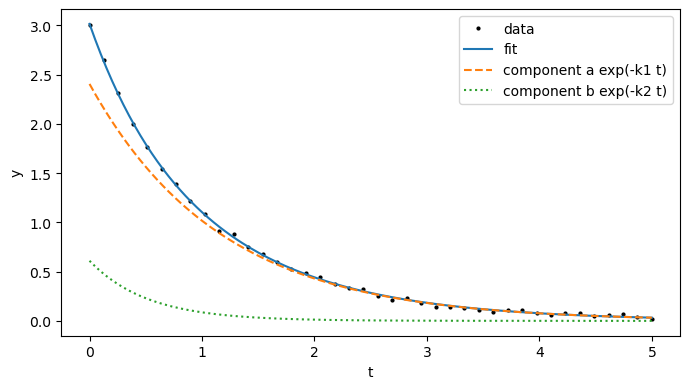

In [3]:
tt = np.linspace(0.0, 5.0, 200)


def curve(p, t):
    return p[0] * np.exp(-p[2] * t) + p[1] * np.exp(-p[3] * t)


p_hat = np.array([pyo.value(m.a), pyo.value(m.b),
                  pyo.value(m.k1), pyo.value(m.k2)])
plt.figure(figsize=(7, 4))
plt.plot(t_data, y_data, "k.", ms=4, label="data")
plt.plot(tt, curve(p_hat, tt), label="fit")
plt.plot(tt, p_hat[0] * np.exp(-p_hat[2] * tt), "--",
         label="component a exp(-k1 t)")
plt.plot(tt, p_hat[1] * np.exp(-p_hat[3] * tt), ":",
         label="component b exp(-k2 t)")
plt.xlabel("t"); plt.ylabel("y"); plt.legend(); plt.tight_layout()
plt.show()

## 2. `eigen()` names the poorly identified combination

The matrix itself first, in natural units, meaning the model's own
units with no solver scaling applied. Read the diagonal as
per-parameter information WITH THE OTHER PARAMETERS HELD FIXED (the
conditional view). That is the mirror image of the covariance
diagonal, which is each parameter's uncertainty AFTER the others are
allowed to adjust (the marginal view). The large off-diagonal entries
are the coupling that makes the marginals so much worse than the
conditionals.

An eigenvector of this matrix is a direction in parameter space, a
recipe for changing all four parameters at once, and its eigenvalue
measures how much information the data carries along that direction.
The eigenvalues then span several orders of magnitude: the small ones
are the directions the data does not inform. The eigenvector of the
smallest eigenvalue is the parameter combination the fit cannot
distinguish, in so many words: trade `a` against `b` while shifting
the rates.

In [4]:
info = information(m)
names = [v.name for v in info.params]
print("information matrix (natural units, order " + str(names) + "):")
print(np.array2string(info.matrix, precision=2, suppress_small=True))
ev, vec = info.eigen()
print("\ninformation eigenvalues (ascending):")
print(np.array2string(ev, precision=3))
print(f"\nspread: {ev[-1] / ev[0]:.1e}")
print("\nleast identified direction (eigenvector of the smallest eigenvalue):")
for n, c in zip(names, vec[:, 0]):
    print(f"   {c:+.3f} * {n}")

information matrix (natural units, order ['a', 'b', 'k1', 'k2']):
[[ 10.09   6.61 -12.58  -1.19]
 [  6.61   5.08  -4.7   -0.61]
 [-12.58  -4.7   35.04   2.06]
 [ -1.19  -0.61   2.06   0.2 ]]

information eigenvalues (ascending):
[1.464e-03 1.003e-01 8.574e+00 4.173e+01]

spread: 2.9e+04

least identified direction (eigenvector of the smallest eigenvalue):
   +0.459 * a
   -0.450 * b
   +0.059 * k1
   +0.764 * k2


Two pictures. The left panel is the identifiability spectrum, four
eigenvalues spanning more than four orders of magnitude. The other two
panels give the physical meaning of its ends. For the data to PIN DOWN
a parameter combination means: moving the parameters along it changes
the model's predictions, so the misfit grows and the data pushes back;
a combination the data does not pin down can be moved along with the
predictions, and so the sum of squared residuals, barely changing.
The LEAST identified direction is the eigenvector of the smallest
eigenvalue, the combination the data pins down least; the BEST
identified direction is the largest eigenvalue's eigenvector, the
combination it pins down most firmly. The two right panels are exactly
that definition drawn: move the parameters the SAME distance along
each, and along the first the curves are indistinguishable, while
along the second the fit visibly breaks. The SSR printed below each
case is the sum of squared residuals, the quantity the fit
minimizes.

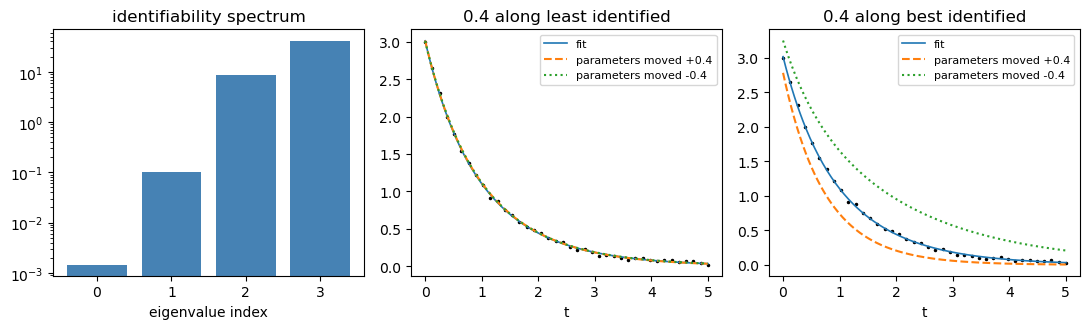

SSR at the fit:                 0.01044
SSR 0.4 along least identified: 0.01147
SSR 0.4 along best identified:  2.06028


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
axes[0].bar(range(len(ev)), ev, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_xlabel("eigenvalue index")
axes[0].set_title("identifiability spectrum")

delta = 0.4
for ax, j, title in ((axes[1], 0, "0.4 along least identified"),
                     (axes[2], -1, "0.4 along best identified")):
    v = vec[:, j]
    ax.plot(t_data, y_data, "k.", ms=3)
    ax.plot(tt, curve(p_hat, tt), lw=1.2, label="fit")
    ax.plot(tt, curve(p_hat + delta * v, tt), "--", label="parameters moved +0.4")
    ax.plot(tt, curve(p_hat - delta * v, tt), ":", label="parameters moved -0.4")
    ax.set_xlabel("t"); ax.set_title(title)
axes[1].legend(fontsize=8)
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()


def sse(p):
    return float(np.sum((y_data - curve(p, t_data)) ** 2))


print("SSR at the fit:                ", round(sse(p_hat), 5))
print("SSR 0.4 along least identified:", round(sse(p_hat + delta * vec[:, 0]), 5))
print("SSR 0.4 along best identified: ", round(sse(p_hat + delta * vec[:, -1]), 5))

## 3. The duality, and Gauss-Newton

Homoscedastic means all data points share one noise level
$\sigma^2$. In that case covariance and information are exact
inverses of one another up to the factor $2\sigma^2$ (the 2 comes
from the objective being a plain sum of squares). The
`hessian="gauss-newton"` option swaps in an approximation built from
first derivatives only: $2J^T J$, where $J$ is the residual Jacobian,
the matrix of derivatives of each residual with respect to each
parameter. Near a good fit with small residuals the two forms agree;
they separate when the residuals are large enough for their own
curvature to matter.

In [6]:
dual = 2.0 * cov.sigma_sq * np.linalg.inv(info.matrix)
resid = np.max(np.abs(cov.matrix / dual - 1.0))
print(f"max relative |cov / (2 sigma^2 inv(info)) - 1| = {resid:.2e}")

info_gn = information(m, hessian="gauss-newton")
print(f"max relative Lagrangian vs Gauss-Newton difference: "
      f"{np.max(np.abs(info.matrix / info_gn.matrix - 1)):.2e}")

max relative |cov / (2 sigma^2 inv(info)) - 1| = 1.03e-04
max relative Lagrangian vs Gauss-Newton difference: 5.60e-04


## 4. At a bound: zero variance is not zero information

A bound is a simple limit on a variable, like $b \ge 2.1$. When
the solution presses against one we say the variable is PINNED, and
the solver carries a multiplier for the bound: the price of the limit,
how fast the objective would improve if the bound moved. POUNCE's
activity classifier reads the converged solve and calls each bound's
status: strongly active (genuinely holding the solution), weakly
active or ambiguous (border cases it will not overcall), or inactive.

First, something the poorly identified model itself teaches. Force `b`
against a bound well above its fitted value: the poorly identified
trade from section 2 absorbs most of the shove, the multiplier stays
weak, and the classifier honestly refuses the strong call, reporting
the activity as ambiguous and keeping `b` at finite variance. A pin
only bites when the data actually resists it.

In [7]:
b_hat = pyo.value(m.b)
mp = build(t_data, y_data)
mp.b.setlb(b_hat + 1.5)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    pyo.SolverFactory("pounce").solve(mp)
    cov_p = covariance(mp)
for w in caught:
    if "ambiguous" in str(w.message):
        print(str(w.message))
print(f"\nvariance of b, pin absorbed: {cov_p[mp.b]:.6g}   (finite, kept)")

covariance: fitted parameter b has ambiguous bound activity at the solve's final barrier parameter; re-solve with a tighter tol to settle it. It is kept in the free block.

variance of b, pin absorbed: 0.532899   (finite, kept)


On a cleanly identified fit the same push bites. This is a SECOND,
separate model with its own synthetic data, a single exponential

$$\hat y(t) = A\; e^{-k t}$$

with only $(A, k)$ fitted; everything before this cell used the
four-parameter model above. Pin `A` above its fitted value: the bound
is strongly active, and `covariance()` reports a zero row for `A`, the
variance conditional on the bound (the uncertainty IF the bound is
taken as given). The information matrix instead returns S: the
information about `A` that remains after the other parameter is
profiled out, meaning allowed to adjust and compensate. S comes from a
standard block-matrix reduction (a Schur complement), but the meaning
is the plain one: how much the data says about `A` on its own. Large,
not zero, and that is the point.

In [8]:
def build_simple(t, y):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, len(t) - 1)
    m.A = pyo.Var(initialize=1.0)
    m.k = pyo.Var(initialize=1.0)
    m.r = pyo.Var(m.I, initialize=0.0)
    @m.Constraint(m.I)
    def res(mm, i):
        return mm.r[i] == float(y[i]) - mm.A * pyo.exp(-mm.k * float(t[i]))
    m.obj = pyo.Objective(expr=sum(m.r[i] ** 2 for i in m.I))
    declare_fitted(m.A, m.k)
    declare_residual(m.r)
    return m

y_simple = (2.0 * np.exp(-0.9 * t_data)
            + 0.02 * rng.standard_normal(len(t_data)))
ms = build_simple(t_data, y_simple)
pyo.SolverFactory("pounce").solve(ms)
A_hat = pyo.value(ms.A)

m2 = build_simple(t_data, y_simple)
m2.A.setlb(A_hat + 0.4)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    pyo.SolverFactory("pounce").solve(m2)
    cov2 = covariance(m2)
    info2 = information(m2)
for w in caught:
    if "strongly active" in str(w.message):
        print(str(w.message))
print(f"\ncovariance  of A at the bound: {cov2[m2.A]:.6g}   (zero row)")
print(f"information of A at the bound: {info2[m2.A]:.6g}   (S, not zero)")
print(f"free-block entry, k:           {info2[m2.k]:.6g}")

covariance: fitted parameter A is held by its bound at the optimum (strongly active); its direction is projected out (zero variance, conditional on the active bound) and the boundary asymptotics are nonstandard.
information: fitted parameter A is held by its bound at the optimum (strongly active); its direction is projected out (zero variance, conditional on the active bound) and the boundary asymptotics are nonstandard.

covariance  of A at the bound: 0   (zero row)
information of A at the bound: 4.28891   (S, not zero)
free-block entry, k:           15.6849


`covariance()` for prediction and reporting, `information()` for
diagnosis: identifiability directions via `eigen()`, experiment-design
reasoning (information adds up over data points), and honest answers
at bounds.